# Proyek Analisis Data: E-commerce Public Dataset
- **Nama:** Azzahra Fitri Ramadhanti
- **Email:** azzahrafitriramadhanti@gmail.com
- **ID Dicoding:** araazhfira

## Menentukan Pertanyaan Bisnis

- **Apa 10 kategori produk dengan jumlah item terjual paling banyak di platform E-commerce Brazil, dan bagaimana rata-rata review score masing-masing kategori tersebut berdasarkan data transaksi tahun 2016–2018, untuk mengidentifikasi kategori mana yang perlu ditingkatkan kualitas atau layanannya?**
- **Berapa rata-rata waktu pengiriman aktual (dalam hari) untuk pesanan yang berstatus 'delivered' pada periode 2016–2018, dan negara bagian mana yang memiliki rata-rata waktu pengiriman terlama serta paling sering melewati estimasi pengiriman, untuk menentukan prioritas wilayah yang membutuhkan perbaikan layanan pengiriman (logistik)??**

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
base_path = '/content/drive/MyDrive/e-commerce/'

In [4]:
customers_df = pd.read_csv(base_path + 'customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
geolocation_df = pd.read_csv(base_path + 'geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [6]:
orderItems_df = pd.read_csv(base_path + 'order_items_dataset.csv')
orderItems_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
orderPayments_df = pd.read_csv(base_path + 'order_payments_dataset.csv')
orderPayments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [8]:
orderReviews_df = pd.read_csv(base_path + 'order_reviews_dataset.csv')
orderReviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [9]:
orders_df = pd.read_csv(base_path + 'orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
productCategory_df = pd.read_csv(base_path + 'product_category_name_translation.csv')
productCategory_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [11]:
products_df = pd.read_csv(base_path + 'products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [12]:
sellers_df = pd.read_csv(base_path + 'sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- **customers_df**: Berisi informasi demografi pelanggan, termasuk ID unik pelanggan, kode pos, kota, dan negara bagian. Terdapat dua jenis ID pelanggan: `customer_id` (ID per pesanan) dan `customer_unique_id` (ID unik untuk pelanggan di seluruh pesanan).
- **geolocation_df**: Berisi data geografis (lintang dan bujur) berdasarkan kode pos, yang dapat digunakan untuk memetakan lokasi pelanggan atau penjual.
- **orderItems_df**: Berisi detail item tiap user dalam setiap pesanan mereka, termasuk ID pesanan, ID produk, ID penjual, batas waktu pengiriman, harga, dan biaya pengiriman. `order_item_id` menunjukkan kemungkinan ada beberapa item dalam satu pesanan.
- **orderPayments_df**: Berisi informasi pembayaran untuk tiap pesanan, seperti jenis pembayaran, jumlah cicilan, dan nilai pembayaran. `payment_sequential` menunjukkan bahwa satu pesanan dapat memiliki beberapa transaksi pembayaran.
- **orderReviews_df**: Berisi data ulasan pelanggan, termasuk skor ulasan dan komentar, yang terhubung ke ID pesanan.
- **orders_df**: Dataset inti yang menghubungkan ID pelanggan dengan pesanan, berisi informasi penting seperti status pesanan dan timestamp untuk berbagai tahapan siklus pesanan (pembelian, persetujuan, pengiriman ke kurir, pengiriman ke pelanggan, estimasi pengiriman).
- **productCategory_df**: Isinya terjemahan nama kategori produk dari bahasa Portugis ke bahasa Inggris.
- **products_df**: Berisi detail produk seperti ID produk, nama kategori produk, panjang nama dan deskripsi produk, jumlah foto, berat, serta dimensi produk (panjang, tinggi, lebar).
- **sellers_df**: Berisi informasi penjual, termasuk ID unik penjual, kode pos, kota, dan negara bagian.

### Assessing Data

In [13]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [14]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [15]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [16]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [17]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [18]:
geolocation_df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [19]:
print("Jumlah duplikasi: ", geolocation_df.duplicated().sum())

Jumlah duplikasi:  261831


In [20]:
geolocation_df.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [21]:
orderItems_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [22]:
orderItems_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [23]:
print("Jumlah duplikasi: ", orderItems_df.duplicated().sum())

Jumlah duplikasi:  0


In [24]:
orderItems_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [25]:
orderPayments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [26]:
orderPayments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [27]:
print("Jumlah duplikasi: ", orderPayments_df.duplicated().sum())

Jumlah duplikasi:  0


In [28]:
orderPayments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [29]:
# Cek baris dengan min payment_value = 0
print(orderPayments_df[orderPayments_df['payment_value'] == 0])

                                order_id  payment_sequential payment_type  \
19922   8bcbe01d44d147f901cd3192671144db                   4      voucher   
36822   fa65dad1b0e818e3ccc5cb0e39231352                  14      voucher   
43744   6ccb433e00daae1283ccc956189c82ae                   4      voucher   
51280   4637ca194b6387e2d538dc89b124b0ee                   1  not_defined   
57411   00b1cb0320190ca0daa2c88b35206009                   1  not_defined   
62674   45ed6e85398a87c253db47c2d9f48216                   3      voucher   
77885   fa65dad1b0e818e3ccc5cb0e39231352                  13      voucher   
94427   c8c528189310eaa44a745b8d9d26908b                   1  not_defined   
100766  b23878b3e8eb4d25a158f57d96331b18                   4      voucher   

        payment_installments  payment_value  
19922                      1            0.0  
36822                      1            0.0  
43744                      1            0.0  
51280                      1            0.0  

In [30]:
# Cek payment_type nya apa saja
print(orderPayments_df[orderPayments_df['payment_value'] == 0]['payment_type'].value_counts())

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64


In [31]:
# Cek baris dengan payment_installments = 0
print(orderPayments_df[orderPayments_df['payment_installments'] == 0])

                               order_id  payment_sequential payment_type  \
46982  744bade1fcf9ff3f31d860ace076d422                   2  credit_card   
79014  1a57108394169c0b47d8f876acc9ba2d                   2  credit_card   

       payment_installments  payment_value  
46982                     0          58.69  
79014                     0         129.94  


In [32]:
# Cek payment_value = 0
print("Payment value = 0:")
print(orderPayments_df[orderPayments_df['payment_value'] == 0]['payment_type'].value_counts())

# Cek payment_installments = 0 tapi payment_value > 0
print("\nInstallments = 0 tapi ada nilai pembayaran:")
print(orderPayments_df[
    (orderPayments_df['payment_installments'] == 0) &
    (orderPayments_df['payment_value'] > 0)
][['payment_type', 'payment_installments', 'payment_value']])

Payment value = 0:
payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

Installments = 0 tapi ada nilai pembayaran:
      payment_type  payment_installments  payment_value
46982  credit_card                     0          58.69
79014  credit_card                     0         129.94


In [33]:
orderReviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [34]:
orderReviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [35]:
print("Jumlah duplikasi: ", orderReviews_df.duplicated().sum())

Jumlah duplikasi:  0


In [36]:
orderReviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [37]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [38]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [39]:
# Cek status pesanan yang missing di kolom-kolom tersebut
print(orders_df[orders_df['order_delivered_customer_date'].isna()]['order_status'].value_counts())

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [40]:
# Cek pesanan yang statusnya delivered tapi tanggal terimanya tidak ada
inconsistent_delivered = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_delivered_customer_date'].isna())
]
print(f"Pesanan delivered tanpa tanggal terima: {len(inconsistent_delivered)}")

Pesanan delivered tanpa tanggal terima: 8


In [41]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [42]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [43]:
productCategory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [44]:
productCategory_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [45]:
print("Jumlah duplikasi: ", productCategory_df.duplicated().sum())

Jumlah duplikasi:  0


In [46]:
productCategory_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [47]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [48]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [49]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [50]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [51]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [52]:
sellers_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [53]:
print("Jumlah duplikasi: ", sellers_df.duplicated().sum())

Jumlah duplikasi:  0


In [54]:
sellers_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- **customers_df**: Datanya lengkap dan bersih, tidak ada nilai yang hilang atau duplikasi. Semua kolom memiliki tipe data yang sesuai.
- **geolocation_df**: Terdapat **261.831 data duplikat**. Tidak ada nilai yang hilang.
- **orderItems_df**: Data lengkap dan bersih, tidak ada nilai yang hilang atau duplikasi. Kolom `shipping_limit_date` saat ini bertipe `object` dan perlu dikonversi ke tipe data datetime untuk analisis waktu.
- **orderPayments_df**: Data lengkap dan bersih, tidak ada nilai yang hilang atau duplikasi. Namun, terdapat nilai minimum 0 pada `payment_installments` dan `payment_value` yang mungkin perlu diperiksa lebih lanjut untuk memahami apakah ini anomali atau merupakan skenario pembayaran yang valid (misalnya, pembayaran yang dibatalkan atau pembayaran tunai tanpa cicilan).
- **orderReviews_df**: Kolom `review_comment_title` dan `review_comment_message` memiliki banyak nilai yang hilang (masing-masing 87.656 dan 58.247). Kolom tanggal `review_creation_date` dan `review_answer_timestamp` perlu dikonversi ke tipe data datetime.
- **orders_df**: Terdapat nilai yang hilang pada kolom `order_approved_at` (160), `order_delivered_carrier_date` (1.783), dan `order_delivered_customer_date` (2.965). Semua kolom timestamp (termasuk `order_purchase_timestamp` dan `order_estimated_delivery_date`) saat ini bertipe `object` dan perlu dikonversi ke tipe data datetime.
- **productCategory_df**: Data lengkap dan bersih, tidak ada nilai yang hilang atau duplikasi. Semua kolom memiliki tipe data yang sesuai.
- **products_df**: Terdapat nilai yang hilang pada beberapa kolom, yaitu `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty` (masing-masing 610 nilai hilang), serta `product_weight_g`, `product_length_cm`, `product_height_cm`, dan `product_width_cm` (masing-masing 2 nilai hilang). Dan untuk kolom `product_category_name` memiliki 73 kategori unik.
- **sellers_df**: Data lengkap dan bersih, tidak ada nilai yang hilang atau duplikasi. Semua kolom memiliki tipe data yang sesuai.

Dari insight deskripsi tiap dataset, maka selanjutnya perlu membersihkan duplikasi di `geolocation_df`, mengisi atau menangani nilai yang hilang di `orderReviews_df`, `orders_df`, dan `products_df`, serta mengonversi kolom tanggal yang relevan ke tipe data datetime di `orderItems_df`, `orderReviews_df`, dan `orders_df`.

### Cleaning Data

In [55]:
# Menghapus duplikat pada geolocation
geolocation_df.drop_duplicates(inplace=True)
print(f"Jumlah duplikasi setelah dihapus: {geolocation_df.duplicated().sum()}")

Jumlah duplikasi setelah dihapus: 0


In [56]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 33.8+ MB


In [57]:
# Konversi kolom shipping_limit_date jadi bertipe datetime
orderItems_df['shipping_limit_date'] = pd.to_datetime(orderItems_df['shipping_limit_date'])
orderItems_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [58]:
orderItems_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [59]:
# Isi nilai hilang pada kolom review_comment_tittle dan review_comment_message
# Konversi kolom review_creation_date dan review_answer_timestamp jadi bertipe datetime
orderReviews_df['review_comment_title'].fillna('no_comment_title', inplace=True)
orderReviews_df['review_comment_message'].fillna('no_comment_message', inplace=True)

orderReviews_df['review_creation_date'] = pd.to_datetime(orderReviews_df['review_creation_date'])
orderReviews_df['review_answer_timestamp'] = pd.to_datetime(orderReviews_df['review_answer_timestamp'])
orderReviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


/tmp/ipykernel_4499/2338904664.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orderReviews_df['review_comment_title'].fillna('no_comment_title', inplace=True)
/tmp/ipykernel_4499/2338904664.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

In [60]:
orderReviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,no_comment_title,no_comment_message,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,no_comment_title,no_comment_message,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,no_comment_title,no_comment_message,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,no_comment_title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,no_comment_title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [61]:
# Drop 3 baris not_defined dengan payment_value = 0
orderPayments_df = orderPayments_df[~(
    (orderPayments_df['payment_type'] == 'not_defined') &
    (orderPayments_df['payment_value'] == 0)
)]

# Fix 2 baris credit_card dengan payment_installments = 0 -> isi 1
orderPayments_df.loc[
    (orderPayments_df['payment_installments'] == 0) &
    (orderPayments_df['payment_type'] == 'credit_card'),
    'payment_installments'
] = 1

# Verifikasi
print(f"Shape setelah cleaning: {orderPayments_df.shape}")
print(f"\nnot_defined payment_value=0 tersisa: {len(orderPayments_df[(orderPayments_df['payment_type'] == 'not_defined') & (orderPayments_df['payment_value'] == 0)])}")
print(f"credit_card installments=0 tersisa: {len(orderPayments_df[(orderPayments_df['payment_installments'] == 0) & (orderPayments_df['payment_type'] == 'credit_card')])}")

Shape setelah cleaning: (103883, 5)

not_defined payment_value=0 tersisa: 0
credit_card installments=0 tersisa: 0


In [62]:
# Konversi semua kolom tanggal ke tipe data datetime
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column], errors='coerce')

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [63]:
# Isi nilai hilang pada product_category_name dengan 'unknown'
products_df['product_category_name'].fillna('unknown', inplace=True)

# Isi nilai hilang pada kolom numerik dengan median
numeric_cols_to_fill = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'
]

for col in numeric_cols_to_fill:
    median_val = products_df[col].median()
    products_df[col].fillna(median_val, inplace=True)

products_df.isna().sum()

/tmp/ipykernel_4499/1253799231.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name'].fillna('unknown', inplace=True)
/tmp/ipykernel_4499/1253799231.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
Setelah proses pembersihan data:
- **`geolocation_df`**: Data duplikat (sebanyak 261.831) telah dihapus, sehingga memastikan tiap kombinasi kode pos-lokasi unik.
- **`orderItems_df`**: Kolom `shipping_limit_date` telah berhasil dikonversi ke tipe data datetime.
- **`orderReviews_df`**: Nilai yang hilang pada kolom `review_comment_title` dan `review_comment_message` telah diisi dengan placeholder 'no_comment_title' dan 'no_comment_message', sementara kolom `review_creation_date` dan `review_answer_timestamp` telah dikonversi ke tipe data datetime.
- **`orders_df`**: Semua kolom timestamp (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) telah berhasil dikonversi ke tipe data datetime. Nilai yang tidak dapat dikonversi atau memang kosong tetap dipertahankan sebagai `NaT` (Not a Time), yang sesuai untuk merepresentasikan peristiwa yang belum terjadi atau informasi yang tidak tersedia.
- **`products_df`**: Kolom numerik seperti `product_name_lenght`, `product_description_lenght`, dan `product_photos_qty` akan diisi dengan nilai mediannya. Median dipilih karena dianggap lebih robust terhadap outlier dibandingkan mean. Begitu pun utnuk (`product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`) juga diisi dengan nilai mediannya.
- `order_Payments_df` memiliki nilai minimum payment 0, yang setelah diselidiki, ditemukan dua permasalahan:
1. **9 baris dengan `payment_value = 0`**
   - 6 baris bertipe `voucher` -> **dipertahankan** karena valid secara bisnis.
     Voucher dapat berfungsi sebagai pelengkap metode pembayaran lain sehingga
     nilai tunainya bisa 0.
   - 3 baris bertipe `not_defined` -> **di-drop** karena tipe pembayaran tidak
     dikenali dan nilai transaksinya 0, sehingga tidak memberikan informasi yang valid.

2. **2 baris `credit_card` dengan `payment_installments = 0`**
   Secara logis bisnis, transaksi menggunakan kartu kredit minimal harus memiliki
   1 cicilan (bayar lunas = 1 cicilan). Kedua baris ini memiliki `payment_value` > 0
   (58.69 dan 129.94), menandakan transaksi benar-benar terjadi namun terdapat
   kesalahan pencatatan pada kolom `payment_installments`. Nilai dikoreksi menjadi 1 daripada di-drop untuk mempertahankan data transaksi yang valid.

## Exploratory Data Analysis (EDA)

In [64]:
customers_df.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [65]:
# Jumlah pelanggan per negara bagian
customers_df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False)

,customer_unique_id
customer_state,
SP,40302
RJ,12384
MG,11259
RS,5277
PR,4882
SC,3534
BA,3277
DF,2075
ES,1964


In [66]:
# Jumlah pelanggan per kota (top 10)
customers_df.groupby('customer_city')['customer_unique_id'].nunique().sort_values(ascending=False).head(10)

,customer_unique_id
customer_city,
sao paulo,14984
rio de janeiro,6620
belo horizonte,2672
brasilia,2069
curitiba,1465
campinas,1398
porto alegre,1326
salvador,1209
guarulhos,1153


**Insight:**
- Pelanggan terbanyak berada di negara bagian **SP (São Paulo)**.
- Kota **São Paulo** dan **Rio de Janeiro** mendominasi jumlah pelanggan terbesar.
- `customer_unique_id` lebih sedikit dari `customer_id`, menandakan sejumlah pelanggan melakukan lebih dari satu pembelian.

In [67]:
orders_df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [68]:
# Distribusi status pesanan
orders_df.groupby('order_status')['order_id'].nunique().sort_values(ascending=False)

,order_id
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [69]:
# Feature engineering: hitung waktu pengiriman aktual dan selisih vs estimasi
# actual_delivery_time: hari dari pembelian hingga diterima pelanggan
orders_df['actual_delivery_time'] = (
    orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']
).dt.days

# delivery_vs_estimated: positif = lebih cepat dari estimasi, negatif = terlambat
orders_df['delivery_vs_estimated'] = (
    orders_df['order_estimated_delivery_date'] - orders_df['order_delivered_customer_date']
).dt.days

# Statistik hanya untuk pesanan berstatus 'delivered'
delivered_orders = orders_df[orders_df['order_status'] == 'delivered']

print('Distribusi Waktu Pengiriman Aktual (Hari):')
print(delivered_orders['actual_delivery_time'].describe())
print('\nDistribusi Selisih Pengiriman vs Estimasi (Hari):')
print(delivered_orders['delivery_vs_estimated'].describe())

Distribusi Waktu Pengiriman Aktual (Hari):
count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: actual_delivery_time, dtype: float64

Distribusi Selisih Pengiriman vs Estimasi (Hari):
count    96470.000000
mean        10.875889
std         10.182105
min       -189.000000
25%          6.000000
50%         11.000000
75%         16.000000
max        146.000000
Name: delivery_vs_estimated, dtype: float64


**Insight:**
- Sebagian besar pesanan berstatus `delivered`. Status lain seperti `canceled` dan `unavailable` jumlahnya relatif kecil.
- Rata-rata waktu pengiriman aktual sekitar **12 hari**, dengan sebaran yang cukup lebar, ada outlier pengiriman hingga >200 hari.
- Rata-rata `delivery_vs_estimated` bernilai positif (~11 hari), artinya secara umum pesanan tiba **lebih cepat dari estimasi** yang diberikan.

In [70]:
orderItems_df.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,NaN,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,NaN
freq,21,NaN,527,2033,NaN,NaN,NaN
mean,NaN,1.197834,NaN,NaN,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,NaN,1.000000,NaN,NaN,2016-09-19 00:15:34,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,2018-01-26 13:59:35,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,NaN,21.000000,NaN,NaN,2020-04-09 22:35:08,6735.000000,409.680000


In [71]:
# Jumlah item per pesanan
orderItems_df.groupby('order_id')['order_item_id'].max().sort_values(ascending=False).head(10)

,order_item_id
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20
9ef13efd6949e4573a18964dd1bbe7f5,15
428a2f660dc84138d969ccd69a0ab6d5,15
9bdc4d4c71aa1de4606060929dee888c,14
73c8ab38f07dc94389065f7eba4f297a,14
37ee401157a3a0b28c9c6d0ed8c3b24b,13
2c2a19b5703863c908512d135aa6accc,12


In [72]:
# Statistik harga dan biaya pengiriman per penjual
orderItems_df.groupby('seller_id').agg(
    total_items_sold=('order_item_id', 'count'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean')
).sort_values('total_items_sold', ascending=False).head(10)

,total_items_sold,avg_price,avg_freight
seller_id,,,
6560211a19b47992c3666cc44a7e94c0,2033,60.651663,13.753537
4a3ca9315b744ce9f8e9374361493884,1987,100.892260,17.648234
1f50f920176fa81dab994f9023523100,1931,55.380223,18.211170
cc419e0650a3c5ba77189a1882b7556a,1775,58.754039,14.461403
da8622b14eb17ae2831f4ac5b9dab84a,1551,103.311779,16.090103
955fee9216a65b617aa5c0531780ce60,1499,90.174583,16.965297
1025f0e2d44d7041d6cf58b6550e0bfa,1428,97.316912,23.733992
7c67e1448b00f6e969d365cea6b010ab,1364,137.774113,37.839113
ea8482cd71df3c1969d7b9473ff13abc,1203,30.904007,14.584181


**Insight:**
- Satu pesanan dapat berisi hingga 21 item (`order_item_id` max = 21), namun mayoritas pesanan hanya berisi 1 item.
- Rentang harga produk sangat lebar (dari sangat murah hingga ribuan Real), menunjukkan variasi jenis produk yang besar.
- Biaya pengiriman (`freight_value`) bervariasi signifikan, kemungkinan dipengaruhi oleh jarak dan berat produk.

In [73]:
orderReviews_df.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,99224,99224,99224,99224
unique,98410,98673,NaN,4528,36160,NaN,NaN
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,no_comment_title,no_comment_message,NaN,NaN
freq,3,3,NaN,87656,58247,NaN,NaN
mean,NaN,NaN,4.086421,NaN,NaN,2018-01-12 20:49:23.948238336,2018-01-16 00:23:56.977938688
min,NaN,NaN,1.000000,NaN,NaN,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,NaN,NaN,4.000000,NaN,NaN,2017-09-23 00:00:00,2017-09-27 01:53:27.249999872
50%,NaN,NaN,5.000000,NaN,NaN,2018-02-02 00:00:00,2018-02-04 22:41:47.500000
75%,NaN,NaN,5.000000,NaN,NaN,2018-05-16 00:00:00,2018-05-20 12:11:21.500000
max,NaN,NaN,5.000000,NaN,NaN,2018-08-31 00:00:00,2018-10-29 12:27:35


In [74]:
# Distribusi frekuensi skor ulasan
orderReviews_df.groupby('review_score')['review_id'].count().sort_index(ascending=False)

,review_id
review_score,
5,57328
4,19142
3,8179
2,3151
1,11424


**Insight:**
- Skor ulasan **5** adalah yang paling banyak diberikan pelanggan, menunjukkan pembeli merasa puas terhadap barang yang dibeli.
- Namun, skor **1** juga cukup signifikan. Berdasarkan analisis kategori,
  kategori dengan skor ulasan terendah seperti **security_and_services** dan
  **fashion_childrens_clothes** perlu mendapat perhatian lebih dari sisi
  kualitas produk maupun layanan penjualan.

In [75]:
products_df.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32951,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000
unique,32951,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.523656,768.227945,2.166975,2276.376802,30.814725,16.937422,23.196534
std,NaN,NaN,10.156155,629.658469,1.728063,4281.926387,16.914005,13.637175,12.078707
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,344.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,961.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [76]:
# Jumlah produk unik per kategori (top 15)
products_df.groupby('product_category_name')['product_id'].nunique().sort_values(ascending=False).head(15)

,product_id
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


In [77]:
# Rata-rata dimensi fisik produk per kategori (berat)
products_df.groupby('product_category_name').agg(
    product_count=('product_id', 'nunique'),
    avg_weight_g=('product_weight_g', 'mean'),
    avg_photos=('product_photos_qty', 'mean')
).sort_values('product_count', ascending=False).head(10)

,product_count,avg_weight_g,avg_photos
product_category_name,,,
cama_mesa_banho,3029,2456.405084,1.392539
esporte_lazer,2867,2024.670736,2.135333
moveis_decoracao,2657,3008.266842,2.400828
beleza_saude,2444,1434.793781,1.624386
utilidades_domesticas,2335,3020.793576,2.212848
automotivo,1900,2654.650526,2.636842
informatica_acessorios,1639,898.377669,1.987797
brinquedos,1411,1869.356485,2.458540
relogios_presentes,1329,509.287434,2.234011


**Insight:**
- Terdapat **74 kategori produk unik** di platform, namun distribusinya tidak merata,
  beberapa kategori mendominasi jumlah produk sedangkan mayoritas kategori hanya memiliki
  sedikit produk unik.
- Kategori `cama_mesa_banho` (bed_bath_table) memiliki jumlah produk unik terbanyak,
  namun perlu disilangkan dengan data transaksi untuk membuktikan apakah ini juga
  kategori yang paling banyak terjual.
- Berat produk bervariasi signifikan antar kategori — kategori seperti `furniture` dan
  `office_furniture` cenderung memiliki berat rata-rata jauh lebih tinggi dibanding
  kategori seperti `health_beauty`, yang berimplikasi langsung pada biaya pengiriman
  (`freight_value`) dan berpotensi mempengaruhi kepuasan pelanggan.

In [78]:
# Gabung item -> produk -> kategori (bahasa Inggris)
items_category_df = (
    orderItems_df[['order_id', 'product_id', 'order_item_id', 'price']]
    .merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(productCategory_df, on='product_category_name', how='left')
)

# Gabung dengan review score
items_category_reviews_df = items_category_df.merge(
    orderReviews_df[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

print(f'Shape: {items_category_reviews_df.shape}')
items_category_reviews_df.head()

Shape: (113314, 7)


,order_id,product_id,order_item_id,price,product_category_name,product_category_name_english,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,1,58.90,cool_stuff,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,1,239.90,pet_shop,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,1,199.00,moveis_decoracao,furniture_decor,5.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,1,12.99,perfumaria,perfumery,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,1,199.90,ferramentas_jardim,garden_tools,5.0


In [79]:
# Agregasi: jumlah item terjual dan rata-rata skor ulasan per kategori
category_analysis = (
    items_category_reviews_df
    .groupby('product_category_name_english')
    .agg(
        total_items_sold=('order_item_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        total_revenue=("price", "sum")
    )
    .reset_index()
    .sort_values('total_items_sold', ascending=False)
    .reset_index(drop=True)
)

print('Top 10 Kategori Produk Paling Diminati:')
display(category_analysis.head(10))

Top 10 Kategori Produk Paling Diminati:


,product_category_name_english,total_items_sold,avg_review_score,total_revenue
0,bed_bath_table,11270,3.895663,1050936.61
1,health_beauty,9727,4.142768,1263138.54
2,sports_leisure,8700,4.107986,993656.51
3,furniture_decor,8415,3.903493,736282.47
4,computers_accessories,7894,3.930819,919640.54
5,housewares,6989,4.055019,634542.60
6,watches_gifts,6001,4.019160,1206075.33
7,telephony,4550,3.946867,323839.40
8,garden_tools,4361,4.042735,486432.45
9,auto,4256,4.065512,594363.10


**Insight:**
- Kategori **`bed_bath_table`** memimpin dengan 11.270 item terjual, diikuti `health_beauty` (9.727) dan `sports_leisure` (8.700).
- Menariknya, `bed_bath_table` yang paling laku justru punya rata-rata review score (3.89) lebih rendah dari `health_beauty` (4.14) dan `sports_leisure` (4.10), menandakan ada gap kepuasan yang perlu diatasi di kategori ini.

In [80]:
# Gabung orders dengan customers
orders_customers_df = (
    orders_df[['order_id', 'customer_id', 'order_status',
                'actual_delivery_time', 'delivery_vs_estimated']]
    .merge(customers_df[['customer_id', 'customer_state']], on='customer_id', how='left')
)

# Filter hanya pesanan berstatus delivered dan tidak ada NaN
delivery_df = orders_customers_df[
    (orders_customers_df['order_status'] == 'delivered') &
    (orders_customers_df['actual_delivery_time'].notna()) &
    (orders_customers_df['delivery_vs_estimated'].notna())
].copy()

print(f'Jumlah pesanan untuk analisis pengiriman: {len(delivery_df):,}')
delivery_df.head()

Jumlah pesanan untuk analisis pengiriman: 96,470


,order_id,customer_id,order_status,actual_delivery_time,delivery_vs_estimated,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,8.0,7.0,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,13.0,5.0,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,9.0,17.0,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,13.0,12.0,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2.0,9.0,SP


In [81]:
# Agregasi payments per order_id
order_payments_agg_df = orderPayments_df.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum')
).reset_index()

order_payments_agg_df.head()

,order_id,total_payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [82]:
# Agregasi efisiensi pengiriman per negara bagian pelanggan
delivery_by_state = (
    delivery_df
    .groupby('customer_state')
    .agg(
        mean_actual_delivery_time=('actual_delivery_time', 'mean'),
        mean_delivery_vs_estimated=('delivery_vs_estimated', 'mean'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

print('10 Negara Bagian dengan Rata-rata Pengiriman Terlama:')
display(delivery_by_state.sort_values('mean_actual_delivery_time', ascending=False).head(10))

print('\n10 Negara Bagian Paling Sering Melewati Estimasi:')
display(delivery_by_state.sort_values('mean_delivery_vs_estimated', ascending=True).head(10))

10 Negara Bagian dengan Rata-rata Pengiriman Terlama:


,customer_state,mean_actual_delivery_time,mean_delivery_vs_estimated,total_orders
21,RR,28.975610,16.292683,41
3,AP,26.731343,18.686567,67
2,AM,25.986207,18.565517,145
1,AL,24.040302,7.707809,397
13,PA,23.316068,13.066596,946
9,MA,21.117155,8.571827,717
24,SE,21.029851,9.020896,335
5,CE,20.817826,9.804535,1279
0,AC,20.637500,19.725000,80
14,PB,19.953578,12.261122,517



10 Negara Bagian Paling Sering Melewati Estimasi:


,customer_state,mean_actual_delivery_time,mean_delivery_vs_estimated,total_orders
1,AL,24.040302,7.707809,397
9,MA,21.117155,8.571827,717
24,SE,21.029851,9.020896,335
7,ES,15.331830,9.496241,1995
4,BA,18.866400,9.794533,3256
5,CE,20.817826,9.804535,1279
11,MS,15.191155,10.052782,701
25,SP,8.298094,10.075542,40494
16,PI,18.993697,10.306723,476
23,SC,14.475183,10.503384,3546


**Insight:**
- Negara bagian **RR, AP, AM** memiliki rata-rata waktu pengiriman terlama, kemungkinan akibat lokasi geografis yang terpencil dan keterbatasan infrastruktur logistik.
- Negara bagian **AL, MA, SE** paling sering *mendekati* estimasi pengiriman (memiliki selisih positif terkecil).
- Meskipun secara menyeluruh rata-rata pengiriman masih lebih cepat dari estimasi, marginnya lebih kecil, dan disparitas antar wilayah tetap signifikan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Apa 10 kategori produk dengan jumlah item terjual paling banyak di platform E-commerce Brazil, dan bagaimana rata-rata review score masing-masing kategori tersebut berdasarkan data transaksi tahun 2016–2018, untuk mengidentifikasi kategori mana yang perlu ditingkatkan kualitas atau layanannya?

/tmp/ipykernel_4499/355493976.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4499/355493976.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


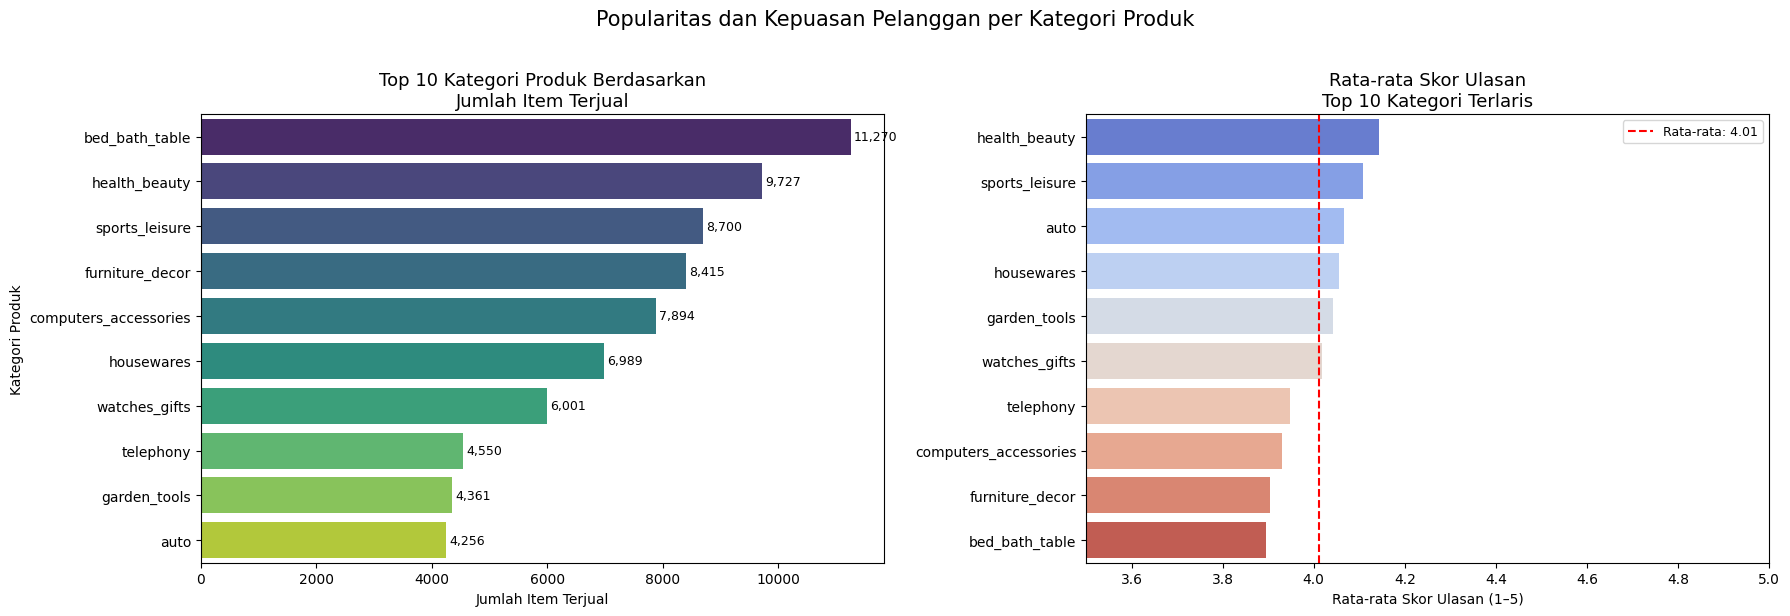

In [83]:
top10 = category_analysis.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Kiri: jumlah item terjual
sns.barplot(
    ax=axes[0],
    x='total_items_sold',
    y='product_category_name_english',
    data=top10,
    palette='viridis',
    legend=False
)
axes[0].set_title('Top 10 Kategori Produk Berdasarkan\nJumlah Item Terjual', fontsize=13)
axes[0].set_xlabel('Jumlah Item Terjual')
axes[0].set_ylabel('Kategori Produk')
for i, v in enumerate(top10['total_items_sold']):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Kanan: rata-rata skor ulasan
sns.barplot(
    ax=axes[1],
    x='avg_review_score',
    y='product_category_name_english',
    data=top10.sort_values('avg_review_score', ascending=False),
    palette='coolwarm',
    legend=False
)
axes[1].set_title('Rata-rata Skor Ulasan\nTop 10 Kategori Terlaris', fontsize=13)
axes[1].set_xlabel('Rata-rata Skor Ulasan (1–5)')
axes[1].set_ylabel('')
axes[1].set_xlim(3.5, 5)
axes[1].axvline(top10['avg_review_score'].mean(), color='red',
                linestyle='--', label=f"Rata-rata: {top10['avg_review_score'].mean():.2f}")
axes[1].legend(fontsize=9)

plt.suptitle('Popularitas dan Kepuasan Pelanggan per Kategori Produk', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4499/1584255635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='avg_review_score', y='product_category_name_english',
/tmp/ipykernel_4499/1584255635.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='avg_review_score', y='product_category_name_english',


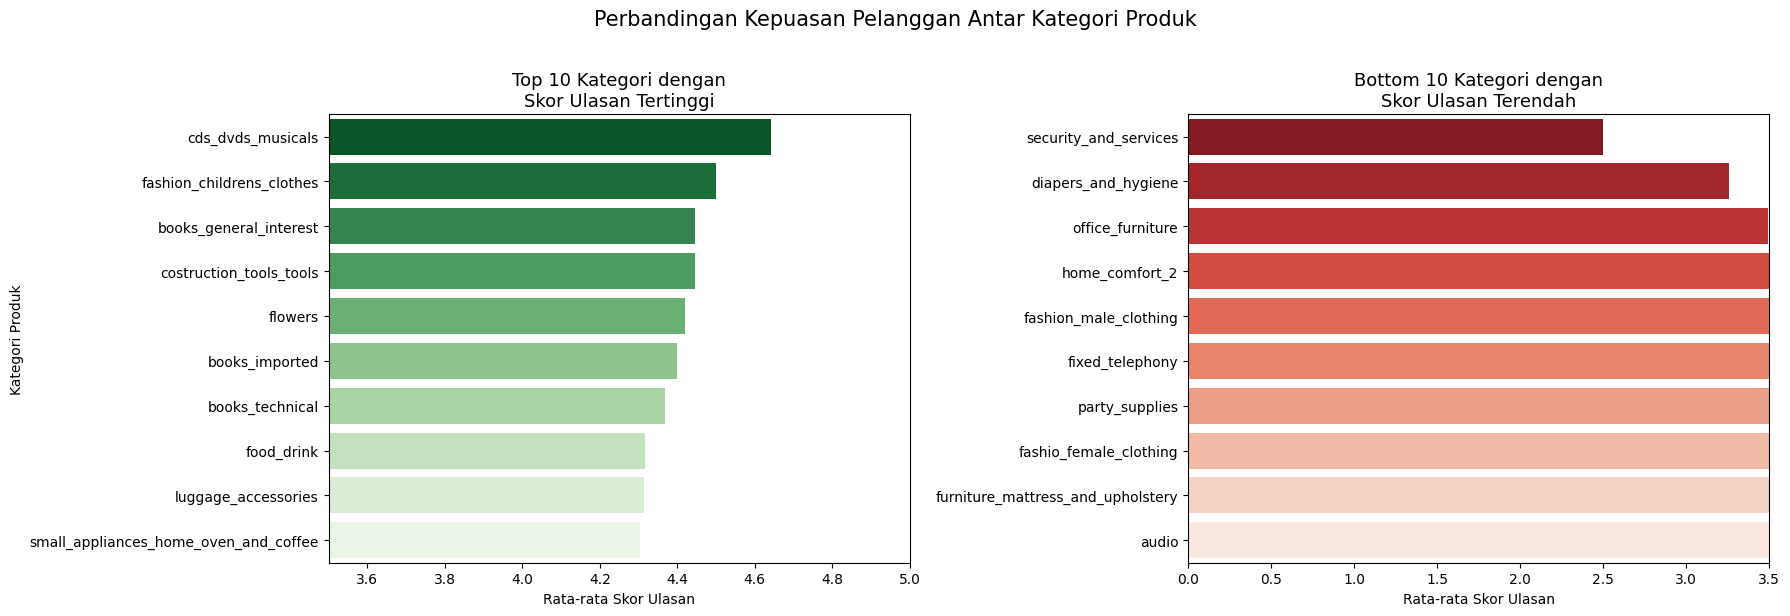

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top10_review  = category_analysis.sort_values('avg_review_score', ascending=False).head(10)
bot10_review  = category_analysis.sort_values('avg_review_score', ascending=True).head(10)

# Kiri: top 10 skor tertinggi
sns.barplot(ax=axes[0], x='avg_review_score', y='product_category_name_english',
            data=top10_review, palette='Greens_r', legend=False)
axes[0].set_title('Top 10 Kategori dengan\nSkor Ulasan Tertinggi', fontsize=13)
axes[0].set_xlabel('Rata-rata Skor Ulasan')
axes[0].set_ylabel('Kategori Produk')
axes[0].set_xlim(3.5, 5)

# Kanan: bottom 10 skor terendah
sns.barplot(ax=axes[1], x='avg_review_score', y='product_category_name_english',
            data=bot10_review, palette='Reds_r', legend=False)
axes[1].set_title('Bottom 10 Kategori dengan\nSkor Ulasan Terendah', fontsize=13)
axes[1].set_xlabel('Rata-rata Skor Ulasan')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 3.5)

plt.suptitle('Perbandingan Kepuasan Pelanggan Antar Kategori Produk', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Berapa rata-rata waktu pengiriman aktual (dalam hari) untuk pesanan yang berstatus 'delivered' pada periode 2016–2018, dan negara bagian mana yang memiliki rata-rata waktu pengiriman terlama serta paling sering melewati estimasi pengiriman, untuk menentukan prioritas wilayah yang membutuhkan perbaikan layanan pengiriman (logistik)?

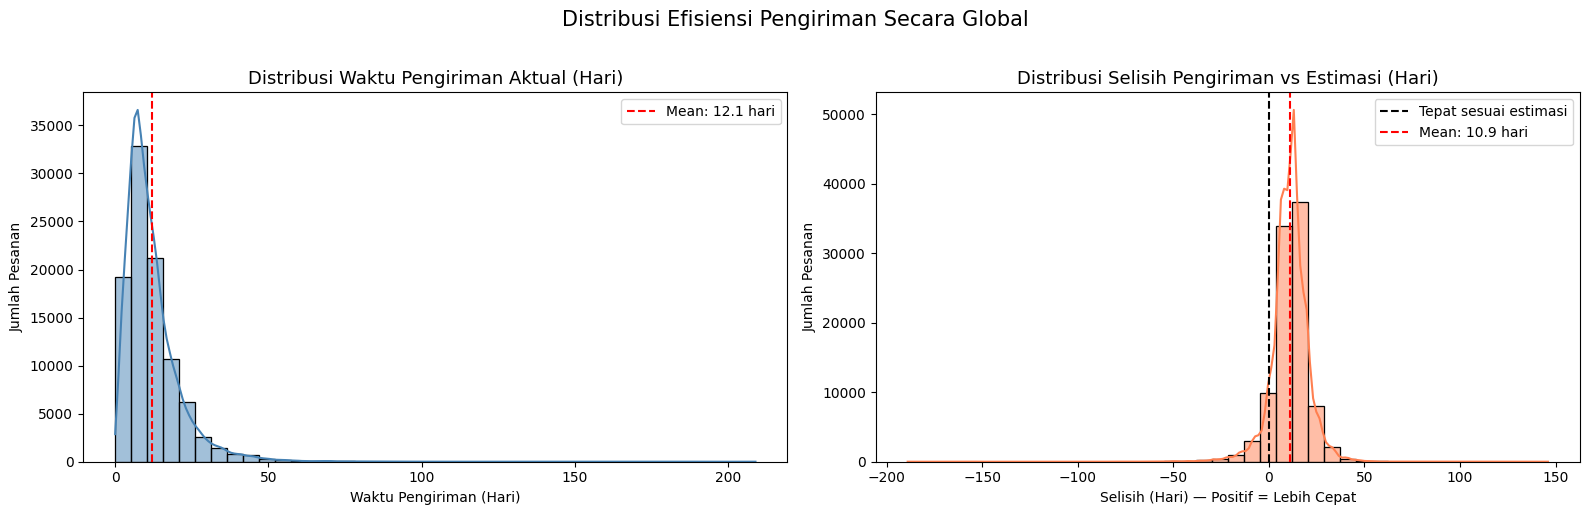

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Kiri: distribusi waktu pengiriman aktual
sns.histplot(ax=axes[0], data=delivery_df, x='actual_delivery_time',
             bins=40, kde=True, color='steelblue')
axes[0].axvline(delivery_df['actual_delivery_time'].mean(), color='red', linestyle='--',
                label=f"Mean: {delivery_df['actual_delivery_time'].mean():.1f} hari")
axes[0].set_title('Distribusi Waktu Pengiriman Aktual (Hari)', fontsize=13)
axes[0].set_xlabel('Waktu Pengiriman (Hari)')
axes[0].set_ylabel('Jumlah Pesanan')
axes[0].legend()

# Kanan: distribusi selisih vs estimasi
sns.histplot(ax=axes[1], data=delivery_df, x='delivery_vs_estimated',
             bins=40, kde=True, color='coral')
axes[1].axvline(0, color='black', linestyle='--', label='Tepat sesuai estimasi')
axes[1].axvline(delivery_df['delivery_vs_estimated'].mean(), color='red', linestyle='--',
                label=f"Mean: {delivery_df['delivery_vs_estimated'].mean():.1f} hari")
axes[1].set_title('Distribusi Selisih Pengiriman vs Estimasi (Hari)', fontsize=13)
axes[1].set_xlabel('Selisih (Hari) — Positif = Lebih Cepat')
axes[1].set_ylabel('Jumlah Pesanan')
axes[1].legend()

plt.suptitle('Distribusi Efisiensi Pengiriman Secara Global', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4499/121947559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='mean_actual_delivery_time', y='customer_state',
/tmp/ipykernel_4499/121947559.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='mean_delivery_vs_estimated', y='customer_state',


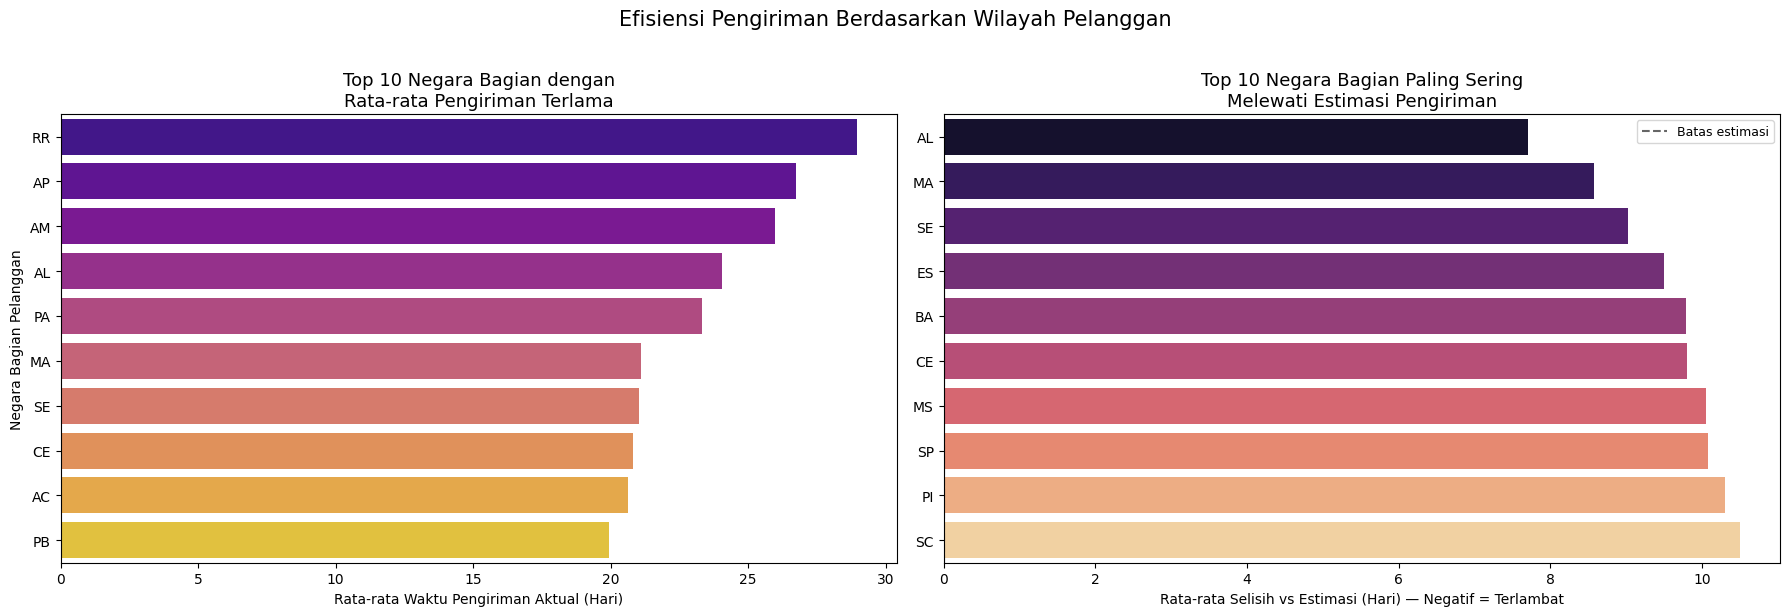

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Kiri: state dengan pengiriman terlama
slowest = delivery_by_state.sort_values('mean_actual_delivery_time', ascending=False).head(10)
sns.barplot(ax=axes[0], x='mean_actual_delivery_time', y='customer_state',
            data=slowest, palette='plasma', legend=False)
axes[0].set_title('Top 10 Negara Bagian dengan\nRata-rata Pengiriman Terlama', fontsize=13)
axes[0].set_xlabel('Rata-rata Waktu Pengiriman Aktual (Hari)')
axes[0].set_ylabel('Negara Bagian Pelanggan')

# Kanan: state paling sering melewati estimasi
latest = delivery_by_state.sort_values('mean_delivery_vs_estimated', ascending=True).head(10)
sns.barplot(ax=axes[1], x='mean_delivery_vs_estimated', y='customer_state',
            data=latest, palette='magma', legend=False)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.6, label='Batas estimasi')
axes[1].set_title('Top 10 Negara Bagian Paling Sering\nMelewati Estimasi Pengiriman', fontsize=13)
axes[1].set_xlabel('Rata-rata Selisih vs Estimasi (Hari) — Negatif = Terlambat')
axes[1].set_ylabel('')
axes[1].legend(fontsize=9)

plt.suptitle('Efisiensi Pengiriman Berdasarkan Wilayah Pelanggan', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Insight dari Seluruh Diagram Visualisasi**:

**1. Popularitas dan Kepuasan Pelanggan per Kategori Produk:**
- Kategori produk **'bed_bath_table'** adalah yang paling populer dengan jumlah item terjual terbanyak (11.270 item), diikuti oleh 'health_beauty' (9.727 item) dan 'sports_leisure' (8.700 item).
- Meskipun 'bed_bath_table' paling laris, rata-rata skor ulasannya (3.89) sedikit di bawah rata-rata keseluruhan dan lebih rendah dari 'health_beauty' (4.14) serta 'sports_leisure' (4.10). Sehingga hal ini menunjukan celah untuk perbaikan kualitas produk atau layanan di kategori 'bed_bath_table' untuk meningkatkan kepuasan pelanggan.
- Kategori dengan skor ulasan tertinggi termasuk 'cds_dvds_musicals' dan 'fashion_childrens_clothes', sementara adalah kategori dengan skor terendah seperti 'security_and_services' dan 'diapers_and_hygiene' sehingga memerlukan perhatian khusus.

**2. Efisiensi Pengiriman:**
- **Waktu Pengiriman Aktual**: Rata-rata waktu pengiriman dari pembelian hingga diterima pelanggan adalah sekitar **12 hari**. Distribusi waktu pengiriman cenderung terkonsentrasi di bawah 30 hari, namun terdapat *outlier* signifikan dengan waktu pengiriman yang mencapai lebih dari 100 hari, bahkan hingga 209 hari.
- **Perbandingan dengan Estimasi**: Secara umum, pengiriman dilakukan **lebih cepat dari estimasi**, dengan rata-rata selisih sekitar 11 hari. Nilai positif menunjukkan pengiriman lebih cepat. Namun, terdapat kasus pengiriman yang sangat terlambat (selisih negatif besar, hingga -189 hari), yang mengindikasikan masalah logistik serius pada pesanan tertentu.

## Analisis Lanjutan (Opsional)

Analisis RFM (Recency, Frequency, Monetary)

In [87]:
# Gabung orders -> customers -> items
rfm_base_df = (
    orders_df[['order_id', 'customer_id', 'order_purchase_timestamp']]
    .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')
    .merge(orderItems_df[['order_id', 'price', 'freight_value']], on='order_id', how='inner')
)

# Total nilai per item
rfm_base_df['total_item_price'] = rfm_base_df['price'] + rfm_base_df['freight_value']

print(f'Shape rfm_base_df: {rfm_base_df.shape}')
rfm_base_df.head()

Shape rfm_base_df: (112650, 7)


,order_id,customer_id,order_purchase_timestamp,customer_unique_id,price,freight_value,total_item_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,28.62


In [88]:
# Hitung RFM per customer_unique_id
latest_date = rfm_base_df['order_purchase_timestamp'].max()

rfm_df = (
    rfm_base_df
    .groupby('customer_unique_id')
    .agg(
        Recency=('order_purchase_timestamp', lambda x: (latest_date - x.max()).days),
        Frequency=('order_id', 'nunique'),
        Monetary=('total_item_price', 'sum')
    )
    .reset_index()
)

print(f'Jumlah pelanggan unik: {len(rfm_df):,}')
display(rfm_df.describe())

Jumlah pelanggan unik: 95,420


,Recency,Frequency,Monetary
count,95420.000000,95420.000000,95420.000000
mean,242.600377,1.034018,166.040172
std,153.160320,0.211234,228.320333
min,0.000000,1.000000,9.590000
25%,118.000000,1.000000,63.100000
50%,223.000000,1.000000,107.940000
75%,352.000000,1.000000,183.220000
max,728.000000,16.000000,13664.080000


Segmentasi Pelanggan Berdasarkan Skor RFM

In [89]:
# Beri skor R, F, M menggunakan kuantil (1–5)
rfm_df['R_score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5, 4, 3, 2, 1])  # Recency rendah = skor tinggi
rfm_df['F_score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm_df['M_score'] = pd.qcut(rfm_df['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm_df['RFM_combined_score'] = (
    rfm_df['R_score'].astype(int) +
    rfm_df['F_score'].astype(int) +
    rfm_df['M_score'].astype(int)
)

def rfm_segment(row):
    score = row['RFM_combined_score']
    if score >= 12:
        return 'Pelanggan Setia'
    elif score >= 9:
        return 'Pelanggan Potensial'
    elif score >= 6:
        return 'Pelanggan Baru'
    else:
        return 'Pelanggan Tidak Aktif'

rfm_df['Customer_Segment'] = rfm_df.apply(rfm_segment, axis=1)

print('Distribusi Segmen Pelanggan:')
display(rfm_df['Customer_Segment'].value_counts())

Distribusi Segmen Pelanggan:


,count
Customer_Segment,
Pelanggan Potensial,38892
Pelanggan Baru,32682
Pelanggan Setia,15827
Pelanggan Tidak Aktif,8019


/tmp/ipykernel_4499/4266245844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Segment', y='count', data=segment_counts,


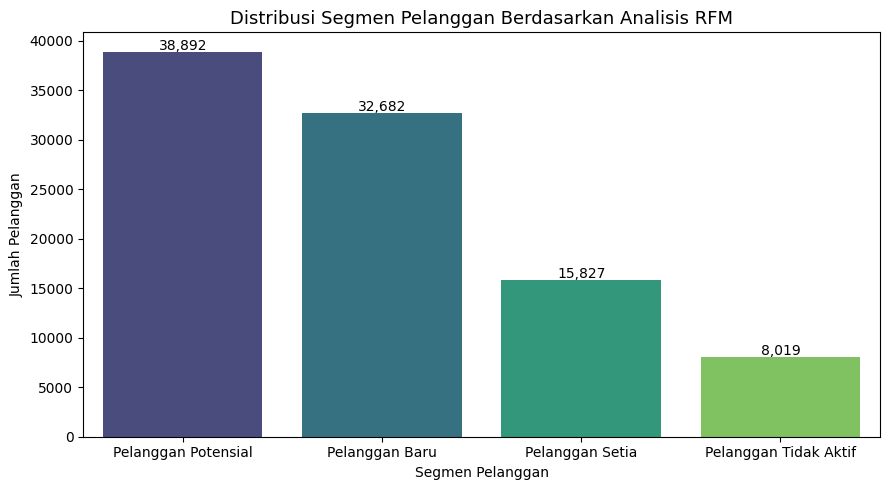

In [90]:
segment_counts = rfm_df['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Customer_Segment', 'count']

plt.figure(figsize=(9, 5))
sns.barplot(x='Customer_Segment', y='count', data=segment_counts,
            palette='viridis', legend=False)
for i, row in segment_counts.iterrows():
    plt.text(i, row['count'] + 200, f"{row['count']:,}", ha='center', fontsize=10)
plt.title('Distribusi Segmen Pelanggan Berdasarkan Analisis RFM', fontsize=13)
plt.xlabel('Segmen Pelanggan')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

**Insight dari Analisis RFM:**
- Mayoritas pelanggan masuk segmen **'Pelanggan Tidak Aktif'**, sudah lama tidak bertransaksi, jarang membeli, dan pengeluaran rendah.
- Segmen **'Pelanggan Setia'** adalah pelanggan paling bernilai dan perlu dipertahankan melalui program loyalitas.
- **'Pelanggan Potensial'** punya peluang menjadi 'Pelanggan Setia' dengan pendekatan yang tepat seperti personalisasi promo atau program referral.

In [91]:
all_df = (
    orders_df
    .merge(customers_df, on='customer_id', how='left')
    .merge(orderReviews_df[['order_id', 'review_score']], on='order_id', how='left')
    .merge(order_payments_agg_df[['order_id', 'total_payment_value']], on='order_id', how='left')
    .merge(orderItems_df, on='order_id', how='left')
    .merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(productCategory_df, on='product_category_name', how='left')
    .merge(sellers_df, on='seller_id', how='left')
    .merge(rfm_df[['customer_unique_id', 'Recency', 'Frequency', 'Monetary',
                    'RFM_combined_score', 'Customer_Segment']], on='customer_unique_id', how='left')
)

In [92]:
all_df.to_csv('main_data.csv', index=False)
print(f'main_data.csv berhasil disimpan — shape: {all_df.shape}')

main_data.csv berhasil disimpan — shape: (114092, 32)


## Conclusion & Recommendation

**Conclusion Pertanyaan 1: Kategori produk paling diminati & kepuasan pelanggan (2016–2018)**

- Kategori **bed_bath_table** adalah yang paling banyak diminati dengan 11.270 item terjual, namun memiliki rata-rata review score terendah di antara top 10 (3.89) dan total revenue 1.050.936, hal ini menunjukkan adanya gap antara popularitas dan kepuasan pembeli pada kategori ini.
- Kategori **health_beauty** mencatatkan total revenue tertinggi (1.263.138) dengan
  review score 4.14, hal ini membuktikan bahwa kategori ini berhasil mempertahankan popularitas
  sekaligus kepuasan pelanggan secara bersamaan.
- Kategori **watches_gifts** cukup menarik perhatian, meskipun hanya berada di peringkat 6
  berdasarkan jumlah item terjual (6.001), revenue-nya mencapai 1.206.075, tertinggi
  kedua, mengindikasikan harga produk per item yang jauh lebih tinggi dibanding kategori
  lain.

**Pertanyaan 2: Efisiensi pengiriman & perbedaan antar wilayah (2016–2018)**

- Rata-rata waktu pengiriman aktual secara global adalah **12 hari**, dengan mayoritas
  pesanan tiba lebih cepat dari estimasi (~11 hari lebih awal).
- Negara bagian **RR (28.97 hari), AP (26.73 hari), dan AM (25.99 hari)** memiliki
  rata-rata waktu pengiriman terlama, selaras dengan tantangan geografis dan
  keterbatasan infrastruktur logistik di wilayah terpencil daerah negara bagian tsb.
- Meskipun RR, AP, AM pengirimannya lama, selisih vs estimasinya masih positif
  (16-18 hari lebih cepat dari estimasi), artinya sistem estimasi di wilayah ini
  sudah cukup akurat mengantisipasi tantangan geografis.
- Negara bagian **AL (7.71 hari vs estimasi)** justru yang paling mengkhawatirkan
  karena selisihnya paling kecil di antara wilayah bermasalah, hampir tidak ada
  buffer antara estimasi dan aktual pengiriman.

**Analisis Lanjutan: Segmentasi Pelanggan RFM**

- Mayoritas pelanggan (38.892) masuk segmen **Pelanggan Potensial** — mereka cukup
  aktif dan memiliki nilai transaksi yang baik, namun belum konsisten berbelanja.
- Segmen **Pelanggan Setia** (15.827) adalah yang paling bernilai bagi platform, frekuensi tinggi, recency rendah, dan monetary tinggi.
- Hanya 8.019 pelanggan masuk segmen **Pelanggan Tidak Aktif** — proporsi yang
  relatif kecil, sehingga mengindikasikan platform cukup berhasil mempertahankan engagement pelanggan secara keseluruhan.

**Rekomendasi Action Item:**
- **Tingkatkan kualitas layanan di kategori bed_bath_table**: sebagai kategori
  terlaris dengan review score rendah (3.89), platform perlu mendorong seller
  untuk meningkatkan deskripsi produk, packaging, dan responsivitas keluhan.
  Misal tetapkan target: naikkan review score ke minimal 4.0 dalam 2 kuartal ke depan.

- **Terapkan strategi health_beauty ke kategori lain**: Jika health_beauty berhasil
  mempertahankan revenue tertinggi sekaligus review score tinggi (4.14). Identifikasi
  praktik terbaik seller di kategori ini dan jadikan benchmark untuk kategori lain
  yang performanya masih di bawah.

- **Optimalkan estimasi pengiriman di wilayah AL, PA, dan BA**: wilayah ini memiliki
  buffer estimasi yang tipis sehingga rentan melewati batas estimasi. Atur ulang atau sesuaikan kembali sistem estimasi dengan menambah buffer waktu minimal 3-5 hari untuk wilayah tersebut.

- **Prioritaskan negosiasi mitra logistik untuk wilayah RR, AP, AM**: meskipun
  estimasinya akurat, waktu pengiriman 26-29 hari terlalu lama dan berpotensi
  menurunkan kepuasan pelanggan jangka panjang. Pertimbangkan mitra logistik lokal
  atau gudang fulfillment di wilayah tersebut.

- **Konversi Pelanggan Potensial menjadi Pelanggan Setia**: dengan 38.892 pelanggan
  di segmen ini, program retensi seperti personalisasi rekomendasi produk, loyalty
  points, atau voucher pembelian kedua dapat mendorong mereka naik segmen dan
  meningkatkan lifetime value pelanggan secara signifikan.